# US NFA accounting in AHP: OpenEcon/FRED replication

This notebook plots every empirical term in

$$
\Delta NFA_t = \Delta FA_t-\Delta FL_t
= \underbrace{G^{A,eq}_t-G^{L,eq}_t}_{VA^{eq}_t}
+\underbrace{P^{A,eq}_t-P^{L,eq}_t+\Delta b_t}_{CA_t}.
$$

The four equity terms are observed directly in the Federal Reserve's Integrated Macroeconomic Accounts (IMA), Table S.9. The bond term is the current-account-closing residual
$\Delta b_t=CA_t-(P^{A,eq}_t-P^{L,eq}_t)$.

Following Atkeson, Heathcote, and Perri (AHP), cumulative flows and positions are divided by contemporaneous US corporate gross value added. The default plot sample is 1990Q1-2023Q3. The downloaded file retains the latest available observations.

Important empirical caveat: the simplified identity omits non-equity valuation changes and the AHP residual. The exact data reconciliation is
$$
\Delta NFA_t=CA_t+VA_t+RES_t.
$$
Thus, the notebook reports both the simplified equity/bond decomposition and the exact AHP reconciliation. Total observed valuation is not a bubble-attributed valuation measure.

In [1]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

DATA_DIR = Path.cwd()
RAW_FILE = DATA_DIR / "fred_ahp_nfa_raw.csv"
METADATA_FILE = DATA_DIR / "fred_ahp_nfa_series_metadata.csv"
FIGURE_DIR = DATA_DIR / "figures_ahp_nfa"
FIGURE_DIR.mkdir(exist_ok=True)

PAPER_START = pd.Timestamp("1990-01-01")
PAPER_END = pd.Timestamp("2023-09-30")

raw = pd.read_csv(RAW_FILE, parse_dates=["date"]).set_index("date").sort_index()
metadata = pd.read_csv(METADATA_FILE)
print(f"Raw data: {raw.index.min().date()} to {raw.index.max().date()} ({len(raw)} rows)")
print(f"Paper plot sample: {PAPER_START.date()} to {PAPER_END.date()}")
metadata[["series_id", "variable", "transformation", "source_url"]]

Raw data: 1989-10-01 to 2026-01-01 (146 rows)
Paper plot sample: 1990-01-01 to 2023-09-30


,series_id,variable,transformation,source_url
0,ROWTLEQ027S,fa_us_level_musd,Use as reported,https://fred.stlouisfed.org/series/ROWTLEQ027S
1,ROWTASQ027S,fl_us_level_musd,Use as reported,https://fred.stlouisfed.org/series/ROWTASQ027S
2,ROWNETQ027S,row_net_worth_level_musd,Multiply by -1 for US NFA,https://fred.stlouisfed.org/series/ROWNETQ027S
3,RWLBACQ027S,row_net_lending_capital_account_saar_musd,US CA_t = -series/4,https://fred.stlouisfed.org/series/RWLBACQ027S
4,BOGZ1FU265000005Q,row_net_lending_financial_account_musd,US NFT_t = -series,https://fred.stlouisfed.org/series/BOGZ1FU2650...
5,RWNEOWQ027S,row_net_worth_revaluation_musd,Total US VA_t = -series,https://fred.stlouisfed.org/series/RWNEOWQ027S
6,BOGZ1FR263181105Q,equity_revaluation_us_held_row_musd,Use as reported,https://fred.stlouisfed.org/series/BOGZ1FR2631...
7,BOGZ1FR263081115Q,equity_revaluation_foreign_held_us_musd,Subtract from US NFA valuation,https://fred.stlouisfed.org/series/BOGZ1FR2630...
8,BOGZ1FU263181105Q,equity_purchases_us_of_row_musd,Use as reported,https://fred.stlouisfed.org/series/BOGZ1FU2631...
9,BOGZ1FU263081005Q,equity_purchases_row_of_us_musd,Subtract from US net equity purchases,https://fred.stlouisfed.org/series/BOGZ1FU2630...


## Sign conventions and transformations

- Table S.9 is stated from the rest-of-world perspective. US financial assets are ROW liabilities; US financial liabilities are ROW financial assets; US NFA is negative ROW net worth.
- `RWLBACQ027S` is a seasonally adjusted annual rate, so quarterly US current-account flow is `-RWLBACQ027S/4`.
- Corporate GVA is also a seasonally adjusted annual rate. AHP uses it as the scale for positions and cumulative dollar changes, so it is converted from billions to millions but is **not** divided by four.
- Equity revaluations and transactions are quarterly dollar changes and are not annualized.

In [2]:
df = pd.DataFrame(index=raw.index)

# Levels (US perspective), millions of dollars
df["fa_us_musd"] = raw["ROWTLEQ027S"]
df["fl_us_musd"] = raw["ROWTASQ027S"]
df["nfa_us_musd"] = -raw["ROWNETQ027S"]
df["gva_corporate_saar_musd"] = 1000.0 * raw["A451RC1Q027SBEA"]

# Changes in gross and net positions
df["delta_fa_musd"] = df["fa_us_musd"].diff()
df["delta_fl_musd"] = df["fl_us_musd"].diff()
df["delta_nfa_musd"] = df["nfa_us_musd"].diff()

# Equity valuation terms (red block)
df["gain_us_held_row_equity_musd"] = raw["BOGZ1FR263181105Q"]
df["gain_foreign_held_us_equity_musd"] = raw["BOGZ1FR263081115Q"]
df["net_equity_valuation_musd"] = (
    df["gain_us_held_row_equity_musd"] - df["gain_foreign_held_us_equity_musd"]
)

# Equity transaction terms (blue block)
df["purchase_us_of_row_equity_musd"] = raw["BOGZ1FU263181105Q"]
df["purchase_row_of_us_equity_musd"] = raw["BOGZ1FU263081005Q"]
df["net_equity_purchases_musd"] = (
    df["purchase_us_of_row_equity_musd"] - df["purchase_row_of_us_equity_musd"]
)

# Current-account and financial-account closings
df["current_account_us_musd"] = -raw["RWLBACQ027S"] / 4.0
df["net_financial_transactions_us_musd"] = -raw["BOGZ1FU265000005Q"]
df["delta_bond_ca_closing_musd"] = (
    df["current_account_us_musd"] - df["net_equity_purchases_musd"]
)
df["delta_bond_financial_account_musd"] = (
    df["net_financial_transactions_us_musd"] - df["net_equity_purchases_musd"]
)
df["statistical_discrepancy_ca_minus_nft_musd"] = (
    df["current_account_us_musd"] - df["net_financial_transactions_us_musd"]
)

# AHP exact empirical reconciliation
df["total_valuation_us_musd"] = -raw["RWNEOWQ027S"]
df["non_equity_valuation_musd"] = (
    df["total_valuation_us_musd"] - df["net_equity_valuation_musd"]
)
df["ahp_residual_musd"] = (
    df["delta_nfa_musd"] - df["current_account_us_musd"] - df["total_valuation_us_musd"]
)

# Identity diagnostics
df["gross_position_identity_error_musd"] = (
    df["nfa_us_musd"] - (df["fa_us_musd"] - df["fl_us_musd"])
)
df["delta_position_identity_error_musd"] = (
    df["delta_nfa_musd"] - (df["delta_fa_musd"] - df["delta_fl_musd"])
)
df["simplified_rhs_musd"] = (
    df["net_equity_valuation_musd"]
    + df["net_equity_purchases_musd"]
    + df["delta_bond_ca_closing_musd"]
)
df["simplified_identity_gap_musd"] = df["delta_nfa_musd"] - df["simplified_rhs_musd"]
df["exact_ahp_identity_error_musd"] = (
    df["delta_nfa_musd"]
    - df["current_account_us_musd"]
    - df["total_valuation_us_musd"]
    - df["ahp_residual_musd"]
)

sample = df.loc[PAPER_START:PAPER_END].copy()
sample.index.name = "date"

# Ratios to contemporaneous corporate GVA
flow_cols = [
    "delta_fa_musd", "delta_fl_musd", "delta_nfa_musd",
    "gain_us_held_row_equity_musd", "gain_foreign_held_us_equity_musd",
    "net_equity_valuation_musd", "purchase_us_of_row_equity_musd",
    "purchase_row_of_us_equity_musd", "net_equity_purchases_musd",
    "delta_bond_ca_closing_musd", "delta_bond_financial_account_musd",
    "current_account_us_musd", "net_financial_transactions_us_musd",
    "total_valuation_us_musd", "non_equity_valuation_musd", "ahp_residual_musd",
    "simplified_rhs_musd", "simplified_identity_gap_musd",
]
level_cols = ["fa_us_musd", "fl_us_musd", "nfa_us_musd"]
for col in level_cols + flow_cols:
    sample[col.replace("_musd", "_over_gva")] = sample[col] / sample["gva_corporate_saar_musd"]

# Cumulative terms from 1990Q1, divided by current-quarter corporate GVA
cum_cols = [
    "delta_nfa_musd", "gain_us_held_row_equity_musd",
    "gain_foreign_held_us_equity_musd", "net_equity_valuation_musd",
    "purchase_us_of_row_equity_musd", "purchase_row_of_us_equity_musd",
    "net_equity_purchases_musd", "delta_bond_ca_closing_musd",
    "current_account_us_musd", "total_valuation_us_musd",
    "non_equity_valuation_musd", "ahp_residual_musd",
    "simplified_rhs_musd", "simplified_identity_gap_musd",
]
for col in cum_cols:
    sample[f"cum_{col.replace('_musd', '')}_over_gva"] = (
        sample[col].cumsum() / sample["gva_corporate_saar_musd"]
    )

nfa_initial = df.loc[df.index < PAPER_START, "nfa_us_musd"].dropna().iloc[-1]
sample["nfa_simple_reconstruction_over_gva"] = (
    nfa_initial + sample["simplified_rhs_musd"].cumsum()
) / sample["gva_corporate_saar_musd"]
sample["nfa_exact_reconstruction_over_gva"] = (
    nfa_initial
    + (sample["current_account_us_musd"]
       + sample["total_valuation_us_musd"]
       + sample["ahp_residual_musd"]).cumsum()
) / sample["gva_corporate_saar_musd"]

print("Maximum absolute identity errors (million USD):")
print({
    "NFA level = FA - FL": float(sample["gross_position_identity_error_musd"].abs().max()),
    "Delta NFA = Delta FA - Delta FL": float(sample["delta_position_identity_error_musd"].abs().max()),
    "AHP exact closure": float(sample["exact_ahp_identity_error_musd"].abs().max()),
})
sample.tail(4)

Maximum absolute identity errors (million USD):
{'NFA level = FA - FL': 0.0, 'Delta NFA = Delta FA - Delta FL': 0.0, 'AHP exact closure': 0.0}


,fa_us_musd,fl_us_musd,nfa_us_musd,gva_corporate_saar_musd,delta_fa_musd,delta_fl_musd,delta_nfa_musd,gain_us_held_row_equity_musd,gain_foreign_held_us_equity_musd,net_equity_valuation_musd,...,cum_net_equity_purchases_over_gva,cum_delta_bond_ca_closing_over_gva,cum_current_account_us_over_gva,cum_total_valuation_us_over_gva,cum_non_equity_valuation_over_gva,cum_ahp_residual_over_gva,cum_simplified_rhs_over_gva,cum_simplified_identity_gap_over_gva,nfa_simple_reconstruction_over_gva,nfa_exact_reconstruction_over_gva
date,,,,,,,,,,,,,,,,,,,,,
2022-10-01,27094153.0,42103145.0,-15008992.0,15556843.0,1898433.0,1179508.0,718925.0,2127894.0,1262573.0,865321.0,...,0.119864,-0.998222,-0.878358,-0.299401,0.090311,0.210590,-1.268069,0.300901,-1.265685,-0.964784
2023-01-01,28592061.0,44270342.0,-15678281.0,15847083.0,1497908.0,2167197.0,-669289.0,1073150.0,1372586.0,-299436.0,...,0.108478,-0.985412,-0.876934,-0.325512,0.075958,0.210757,-1.278404,0.286715,-1.276063,-0.989348
2023-04-01,29143642.0,46341265.0,-17197623.0,15964856.0,551581.0,2070923.0,-1519342.0,383261.0,1598301.0,-1215040.0,...,0.103813,-0.988866,-0.885053,-0.395568,0.079047,0.201080,-1.359668,0.280127,-1.357345,-1.077218
2023-07-01,28458974.0,45685919.0,-17226945.0,16204030.0,-684668.0,-655346.0,-29322.0,-950599.0,-834110.0,-116489.0,...,0.106176,-0.992385,-0.886209,-0.376490,0.098309,0.197283,-1.361008,0.295591,-1.358719,-1.063127


In [3]:
# Save the processed, audit-ready quarterly dataset
processed_path = DATA_DIR / "ahp_us_nfa_decomposition_1990q1_2023q3.csv"
sample.reset_index().assign(
    quarter=lambda x: x["date"].dt.to_period("Q").astype(str)
).to_csv(processed_path, index=False, date_format="%Y-%m-%d")
processed_path

PosixPath('/Users/jipengcheng/Library/Mobile Documents/com~apple~CloudDocs/【Research】/Two_country_HKT/Codes/Two_country_production/Data/ahp_us_nfa_decomposition_1990q1_2023q3.csv')

In [4]:
# Period totals: dollar amounts and fractions of end-period corporate GVA
periods = {
    "1990Q1-2001Q4": ("1990-01-01", "2001-12-31"),
    "2002Q1-2007Q4": ("2002-01-01", "2007-12-31"),
    "2008Q1-2022Q4": ("2008-01-01", "2022-12-31"),
    "2008Q1-2023Q3": ("2008-01-01", "2023-09-30"),
}
summary_terms = [
    "delta_nfa_musd", "gain_us_held_row_equity_musd",
    "gain_foreign_held_us_equity_musd", "net_equity_valuation_musd",
    "purchase_us_of_row_equity_musd", "purchase_row_of_us_equity_musd",
    "net_equity_purchases_musd", "delta_bond_ca_closing_musd",
    "current_account_us_musd", "total_valuation_us_musd",
    "non_equity_valuation_musd", "ahp_residual_musd",
]
rows = []
for label, (start, end) in periods.items():
    block = sample.loc[start:end]
    end_gva = block["gva_corporate_saar_musd"].iloc[-1]
    for term in summary_terms:
        total = block[term].sum()
        rows.append({
            "period": label,
            "term": term,
            "total_trillion_usd": total / 1_000_000,
            "total_over_end_period_gva": total / end_gva,
        })
period_summary = pd.DataFrame(rows)
period_summary_path = DATA_DIR / "ahp_us_nfa_period_summary.csv"
period_summary.to_csv(period_summary_path, index=False)
period_summary.pivot(index="term", columns="period", values="total_trillion_usd").round(3)

period,1990Q1-2001Q4,2002Q1-2007Q4,2008Q1-2022Q4,2008Q1-2023Q3
term,,,,
ahp_residual_musd,0.292,1.569,1.415,1.336
current_account_us_musd,-1.943,-3.963,-7.758,-8.454
delta_bond_ca_closing_musd,-2.201,-4.424,-8.904,-9.456
delta_nfa_musd,-1.880,1.204,-14.370,-16.588
gain_foreign_held_us_equity_musd,1.321,0.828,9.585,11.721
gain_us_held_row_equity_musd,0.856,4.481,0.333,0.839
net_equity_purchases_musd,0.258,0.461,1.146,1.002
net_equity_valuation_musd,-0.465,3.653,-9.251,-10.882
non_equity_valuation_musd,0.236,-0.055,1.224,1.412


## Plotting setup

All panels use the AHP convention: fractions of contemporaneous annual-rate US corporate GVA. Shaded bands mark 2002-2007 and the post-2007 period.

In [5]:
plt.style.use("seaborn-v0_8-whitegrid")
COLORS = {
    "red": "#B22222", "red_light": "#E07A5F",
    "blue": "#1F5A94", "blue_light": "#5B8DB8",
    "black": "#111111", "gray": "#777777", "green": "#2A7F62", "purple": "#7B3294",
}

def format_time_axis(ax, zero=True):
    if zero:
        ax.axhline(0, color="#333333", linewidth=0.8)
    ax.axvspan(pd.Timestamp("2002-01-01"), pd.Timestamp("2007-12-31"), color="#F5C66A", alpha=0.13)
    ax.axvspan(pd.Timestamp("2008-01-01"), PAPER_END, color="#90AFC5", alpha=0.08)
    ax.xaxis.set_major_locator(mdates.YearLocator(5))
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
    ax.tick_params(axis="x", rotation=0)
    ax.set_xlim(PAPER_START, PAPER_END)

def finish_figure(fig, filename, title):
    fig.suptitle(title, fontsize=14, fontweight="semibold", y=1.01)
    fig.tight_layout()
    path = FIGURE_DIR / filename
    fig.savefig(path, dpi=220, bbox_inches="tight", facecolor="white")
    plt.show()
    return path

## Figure 1: gross positions and NFA

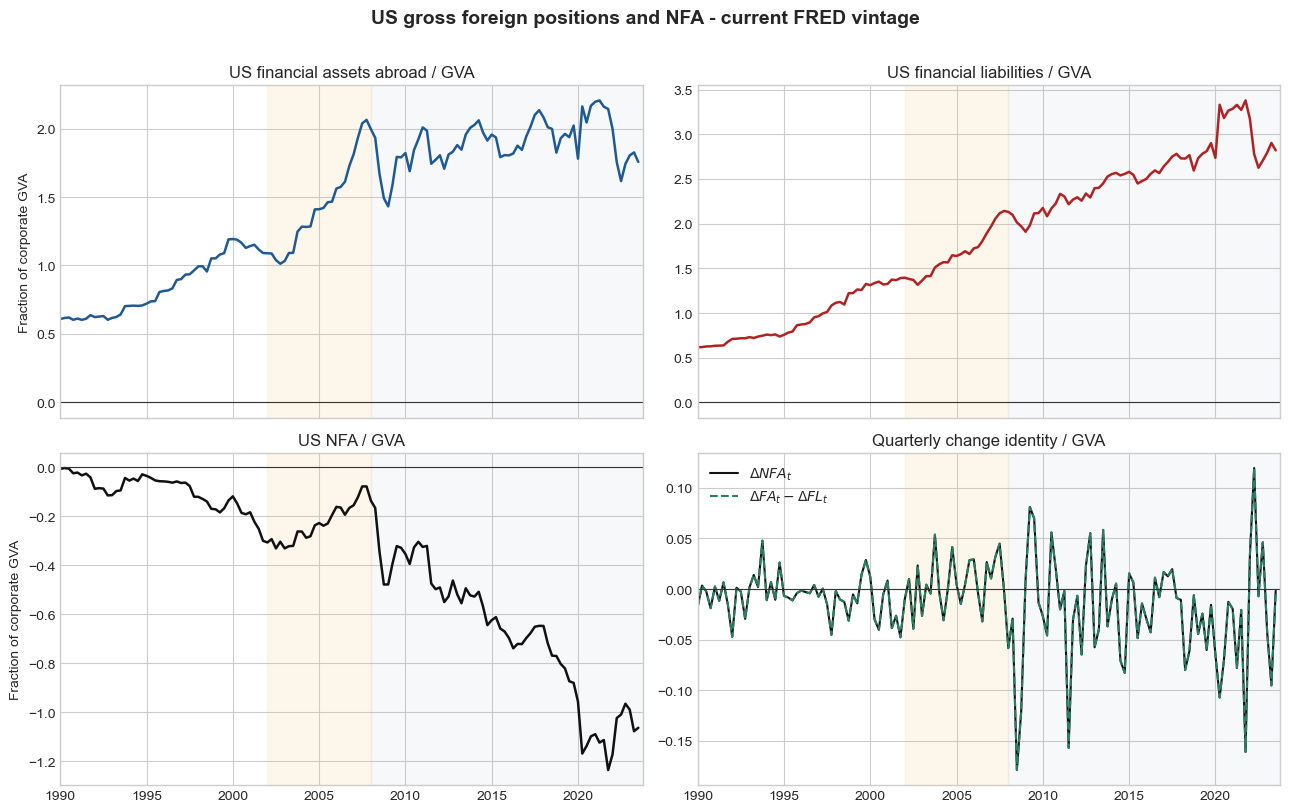

PosixPath('/Users/jipengcheng/Library/Mobile Documents/com~apple~CloudDocs/【Research】/Two_country_HKT/Codes/Two_country_production/Data/figures_ahp_nfa/01_gross_positions_and_nfa_over_gva.png')

In [6]:
fig, axes = plt.subplots(2, 2, figsize=(13, 8), sharex=True)
plots = [
    ("fa_us_over_gva", "US financial assets abroad / GVA", COLORS["blue"]),
    ("fl_us_over_gva", "US financial liabilities / GVA", COLORS["red"]),
    ("nfa_us_over_gva", "US NFA / GVA", COLORS["black"]),
]
for ax, (col, title, color) in zip(axes.flat[:3], plots):
    ax.plot(sample.index, sample[col], color=color, linewidth=1.8)
    ax.set_title(title)
    format_time_axis(ax)
axes[1, 1].plot(sample.index, sample["delta_nfa_over_gva"], color=COLORS["black"], label=r"$\Delta NFA_t$")
axes[1, 1].plot(sample.index, sample["delta_fa_over_gva"] - sample["delta_fl_over_gva"], color=COLORS["green"], linestyle="--", label=r"$\Delta FA_t-\Delta FL_t$")
axes[1, 1].set_title("Quarterly change identity / GVA")
axes[1, 1].legend(frameon=False)
format_time_axis(axes[1, 1])
for ax in axes[:, 0]: ax.set_ylabel("Fraction of corporate GVA")
finish_figure(fig, "01_gross_positions_and_nfa_over_gva.png", "US gross foreign positions and NFA - current FRED vintage")

## Figure 2: every underbraced equity term

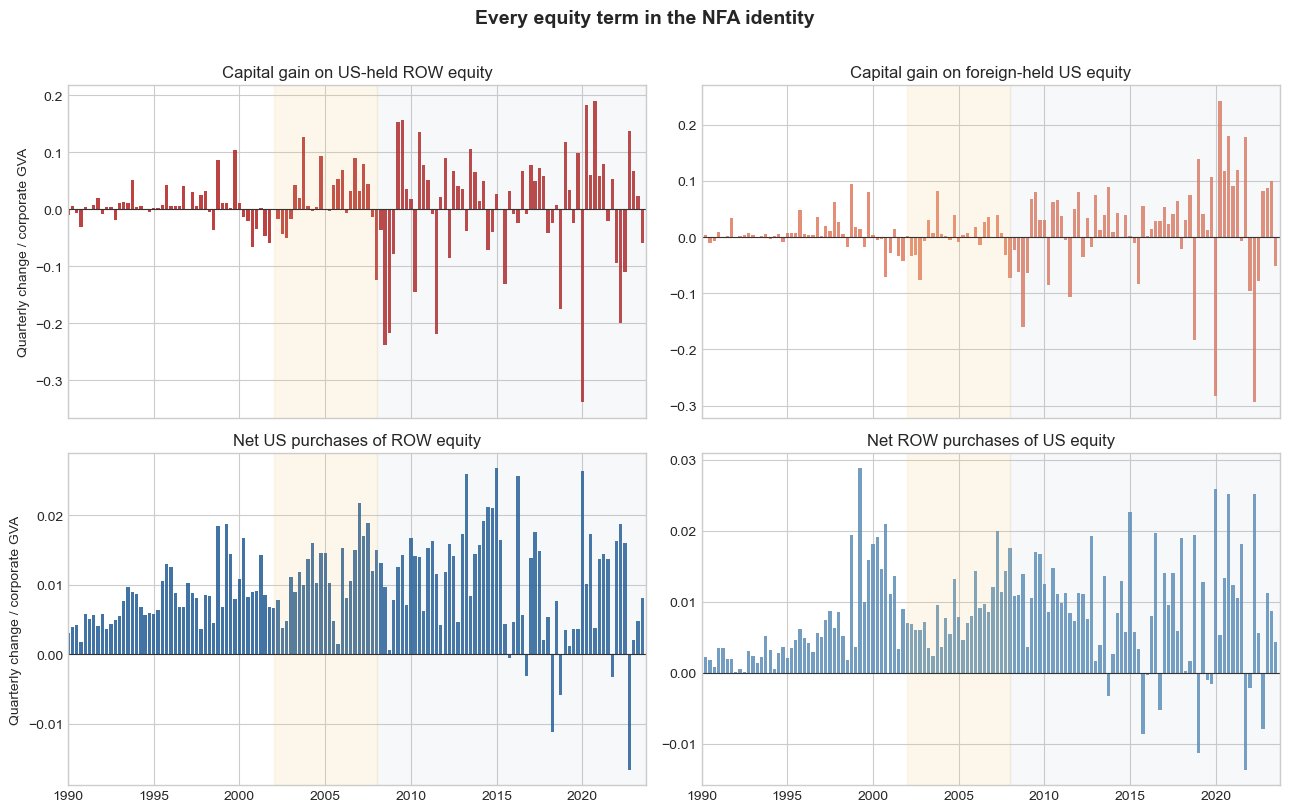

PosixPath('/Users/jipengcheng/Library/Mobile Documents/com~apple~CloudDocs/【Research】/Two_country_HKT/Codes/Two_country_production/Data/figures_ahp_nfa/02_each_equity_term_over_gva.png')

In [7]:
fig, axes = plt.subplots(2, 2, figsize=(13, 8), sharex=True, sharey=False)
panel_specs = [
    ("gain_us_held_row_equity_over_gva", "Capital gain on US-held ROW equity", COLORS["red"]),
    ("gain_foreign_held_us_equity_over_gva", "Capital gain on foreign-held US equity", COLORS["red_light"]),
    ("purchase_us_of_row_equity_over_gva", "Net US purchases of ROW equity", COLORS["blue"]),
    ("purchase_row_of_us_equity_over_gva", "Net ROW purchases of US equity", COLORS["blue_light"]),
]
for ax, (col, title, color) in zip(axes.flat, panel_specs):
    ax.bar(sample.index, sample[col], width=70, color=color, alpha=0.85)
    ax.set_title(title)
    format_time_axis(ax)
for ax in axes[:, 0]: ax.set_ylabel("Quarterly change / corporate GVA")
finish_figure(fig, "02_each_equity_term_over_gva.png", "Every equity term in the NFA identity")

## Figure 3: net valuation, net purchases, bond change, and current account

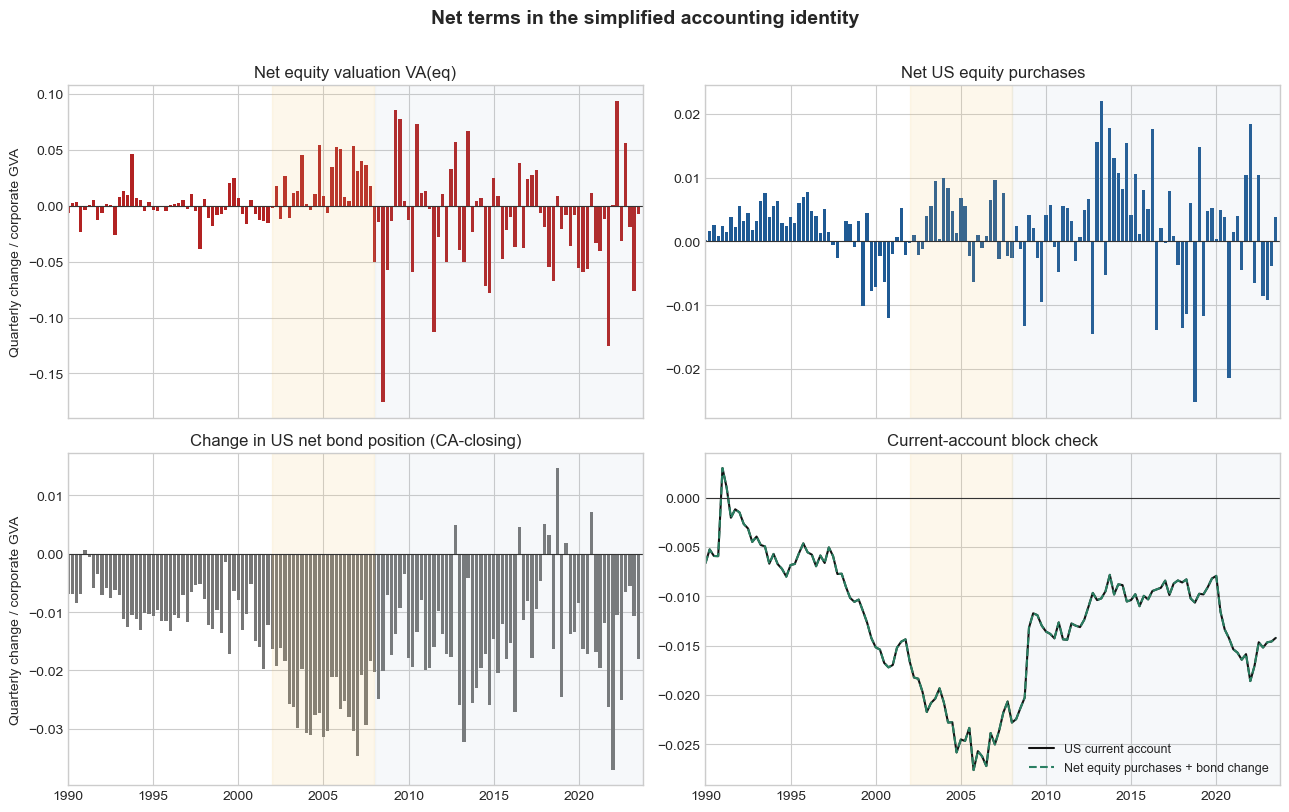

PosixPath('/Users/jipengcheng/Library/Mobile Documents/com~apple~CloudDocs/【Research】/Two_country_HKT/Codes/Two_country_production/Data/figures_ahp_nfa/03_net_terms_and_current_account_over_gva.png')

In [8]:
fig, axes = plt.subplots(2, 2, figsize=(13, 8), sharex=True)
axes[0, 0].bar(sample.index, sample["net_equity_valuation_over_gva"], width=70, color=COLORS["red"])
axes[0, 0].set_title("Net equity valuation VA(eq)")
axes[0, 1].bar(sample.index, sample["net_equity_purchases_over_gva"], width=70, color=COLORS["blue"])
axes[0, 1].set_title("Net US equity purchases")
axes[1, 0].bar(sample.index, sample["delta_bond_ca_closing_over_gva"], width=70, color=COLORS["gray"])
axes[1, 0].set_title("Change in US net bond position (CA-closing)")
axes[1, 1].plot(sample.index, sample["current_account_us_over_gva"], color=COLORS["black"], label="US current account")
axes[1, 1].plot(sample.index, sample["net_equity_purchases_over_gva"] + sample["delta_bond_ca_closing_over_gva"], color=COLORS["green"], linestyle="--", label="Net equity purchases + bond change")
axes[1, 1].set_title("Current-account block check")
axes[1, 1].legend(frameon=False, fontsize=9)
for ax in axes.flat:
    format_time_axis(ax)
for ax in axes[:, 0]: ax.set_ylabel("Quarterly change / corporate GVA")
finish_figure(fig, "03_net_terms_and_current_account_over_gva.png", "Net terms in the simplified accounting identity")

## Figure 4: cumulative underbraced terms

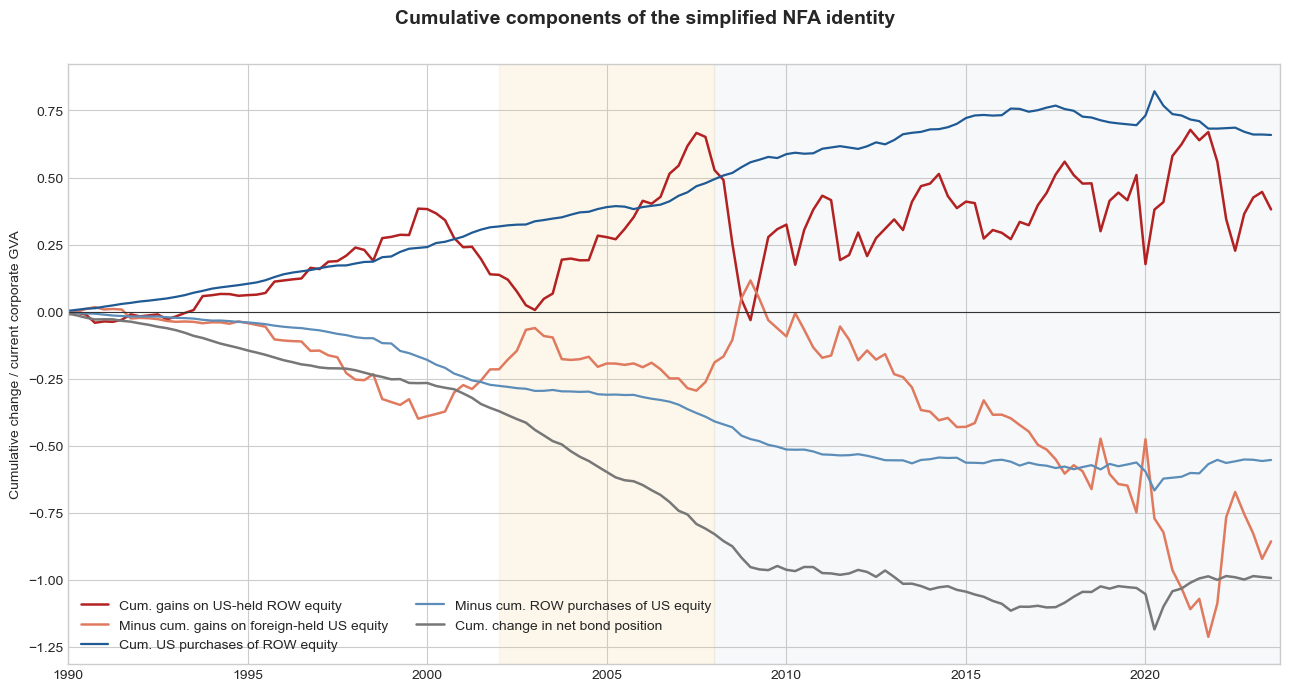

PosixPath('/Users/jipengcheng/Library/Mobile Documents/com~apple~CloudDocs/【Research】/Two_country_HKT/Codes/Two_country_production/Data/figures_ahp_nfa/04_cumulative_underbraced_terms_over_gva.png')

In [9]:
fig, ax = plt.subplots(figsize=(13, 6.8))
ax.plot(sample.index, sample["cum_gain_us_held_row_equity_over_gva"], color=COLORS["red"], linewidth=1.8, label="Cum. gains on US-held ROW equity")
ax.plot(sample.index, -sample["cum_gain_foreign_held_us_equity_over_gva"], color=COLORS["red_light"], linewidth=1.8, label="Minus cum. gains on foreign-held US equity")
ax.plot(sample.index, sample["cum_purchase_us_of_row_equity_over_gva"], color=COLORS["blue"], linewidth=1.6, label="Cum. US purchases of ROW equity")
ax.plot(sample.index, -sample["cum_purchase_row_of_us_equity_over_gva"], color=COLORS["blue_light"], linewidth=1.6, label="Minus cum. ROW purchases of US equity")
ax.plot(sample.index, sample["cum_delta_bond_ca_closing_over_gva"], color=COLORS["gray"], linewidth=1.8, label="Cum. change in net bond position")
format_time_axis(ax)
ax.set_ylabel("Cumulative change / current corporate GVA")
ax.legend(frameon=False, ncol=2, loc="lower left")
finish_figure(fig, "04_cumulative_underbraced_terms_over_gva.png", "Cumulative components of the simplified NFA identity")

## Figure 5: AHP Figure 2-style exact empirical reconciliation

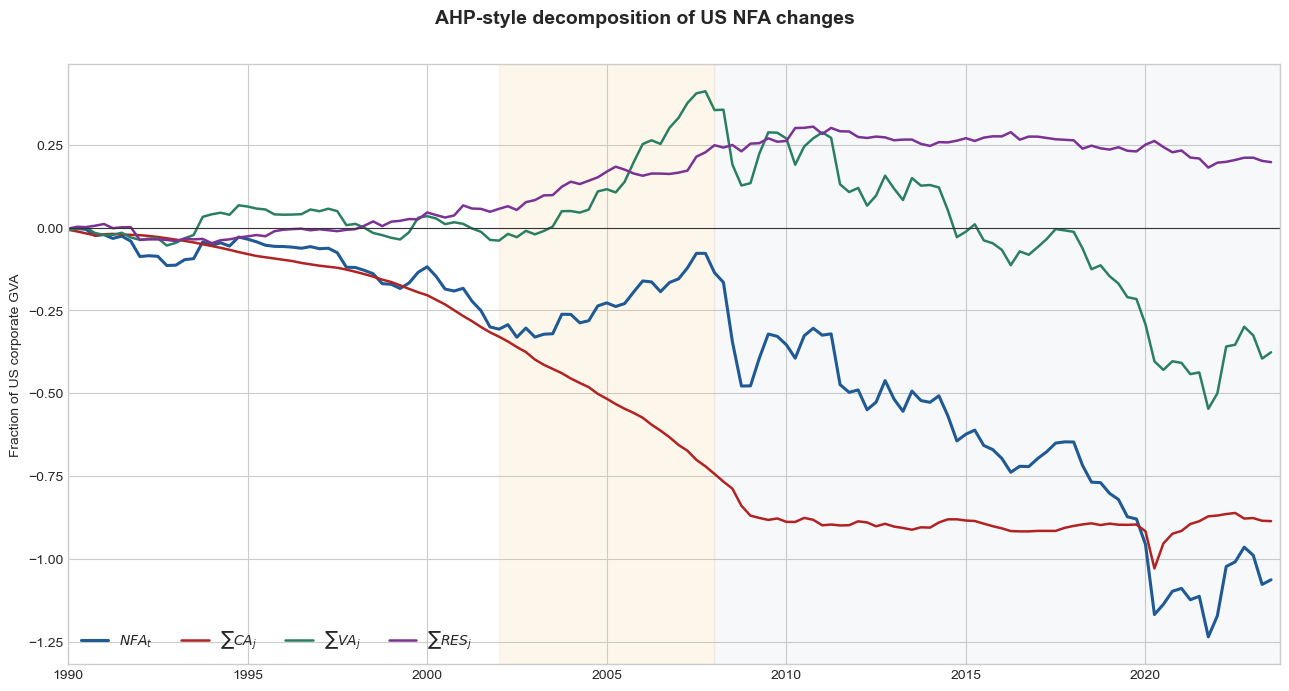

PosixPath('/Users/jipengcheng/Library/Mobile Documents/com~apple~CloudDocs/【Research】/Two_country_HKT/Codes/Two_country_production/Data/figures_ahp_nfa/05_ahp_figure2_current_vintage.png')

In [10]:
fig, ax = plt.subplots(figsize=(13, 6.8))
ax.plot(sample.index, sample["nfa_us_over_gva"], color=COLORS["blue"], linewidth=2.2, label=r"$NFA_t$")
ax.plot(sample.index, sample["cum_current_account_us_over_gva"], color=COLORS["red"], linewidth=1.8, label=r"$\sum CA_j$")
ax.plot(sample.index, sample["cum_total_valuation_us_over_gva"], color=COLORS["green"], linewidth=1.8, label=r"$\sum VA_j$")
ax.plot(sample.index, sample["cum_ahp_residual_over_gva"], color=COLORS["purple"], linewidth=1.8, label=r"$\sum RES_j$")
format_time_axis(ax)
ax.set_ylabel("Fraction of US corporate GVA")
ax.legend(frameon=False, ncol=4, loc="lower left")
finish_figure(fig, "05_ahp_figure2_current_vintage.png", "AHP-style decomposition of US NFA changes")

## Figure 6: simplified identity versus the exact data reconciliation

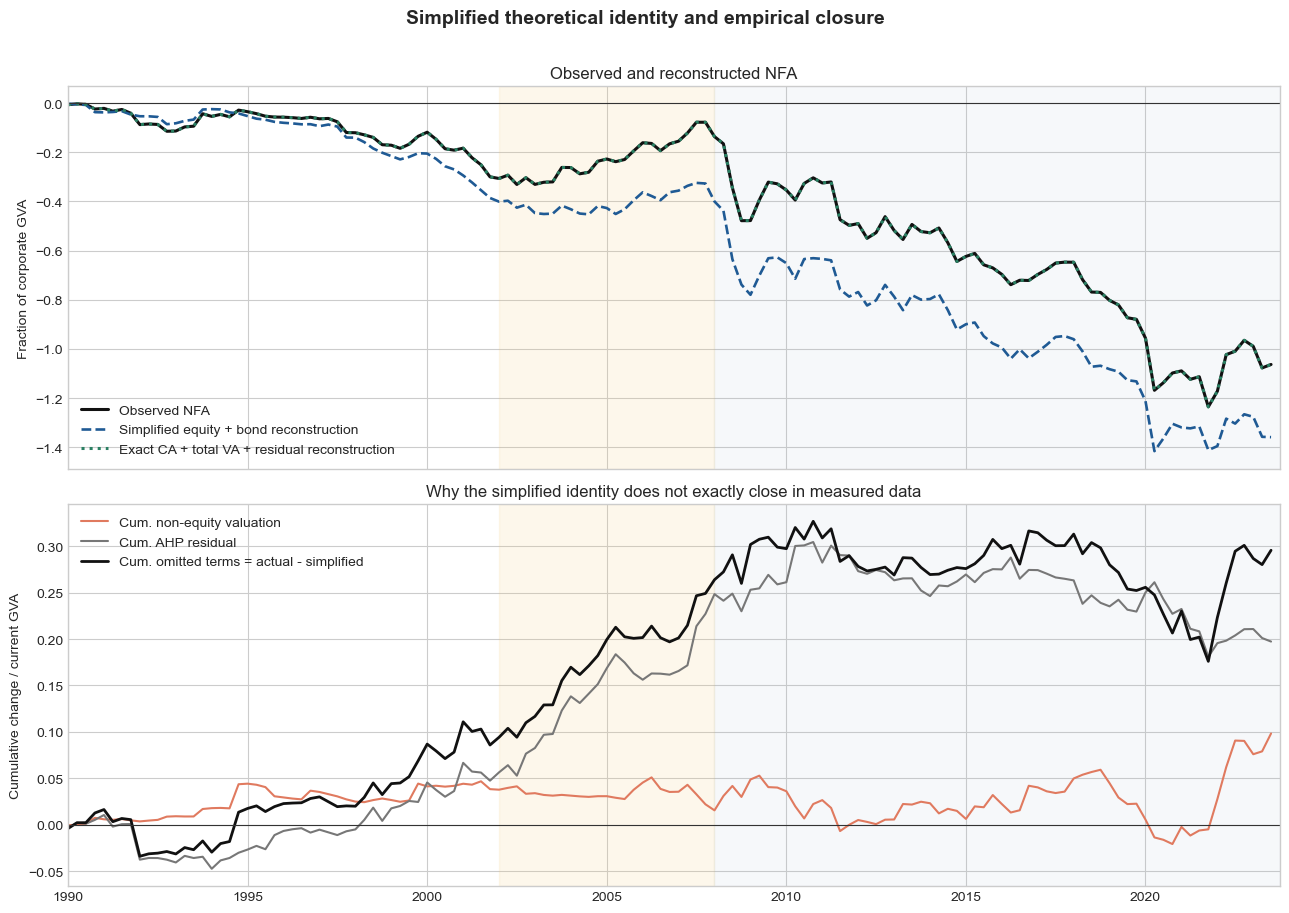

PosixPath('/Users/jipengcheng/Library/Mobile Documents/com~apple~CloudDocs/【Research】/Two_country_HKT/Codes/Two_country_production/Data/figures_ahp_nfa/06_simplified_vs_exact_reconciliation.png')

In [11]:
fig, axes = plt.subplots(2, 1, figsize=(13, 9), sharex=True)
axes[0].plot(sample.index, sample["nfa_us_over_gva"], color=COLORS["black"], linewidth=2.2, label="Observed NFA")
axes[0].plot(sample.index, sample["nfa_simple_reconstruction_over_gva"], color=COLORS["blue"], linestyle="--", linewidth=1.9, label="Simplified equity + bond reconstruction")
axes[0].plot(sample.index, sample["nfa_exact_reconstruction_over_gva"], color=COLORS["green"], linestyle=":", linewidth=2.2, label="Exact CA + total VA + residual reconstruction")
axes[0].set_title("Observed and reconstructed NFA")
axes[0].set_ylabel("Fraction of corporate GVA")
axes[0].legend(frameon=False)
format_time_axis(axes[0])

axes[1].plot(sample.index, sample["cum_non_equity_valuation_over_gva"], color=COLORS["red_light"], label="Cum. non-equity valuation")
axes[1].plot(sample.index, sample["cum_ahp_residual_over_gva"], color=COLORS["gray"], label="Cum. AHP residual")
axes[1].plot(sample.index, sample["cum_simplified_identity_gap_over_gva"], color=COLORS["black"], linewidth=2, label="Cum. omitted terms = actual - simplified")
axes[1].set_title("Why the simplified identity does not exactly close in measured data")
axes[1].set_ylabel("Cumulative change / current GVA")
axes[1].legend(frameon=False)
format_time_axis(axes[1])
finish_figure(fig, "06_simplified_vs_exact_reconciliation.png", "Simplified theoretical identity and empirical closure")

## Figure 7: cumulative equity valuation components

The two signed gross capital-gain terms sum to cumulative net equity valuation, $\sum_s VA_s$, with every series divided by contemporaneous U.S. corporate GVA.

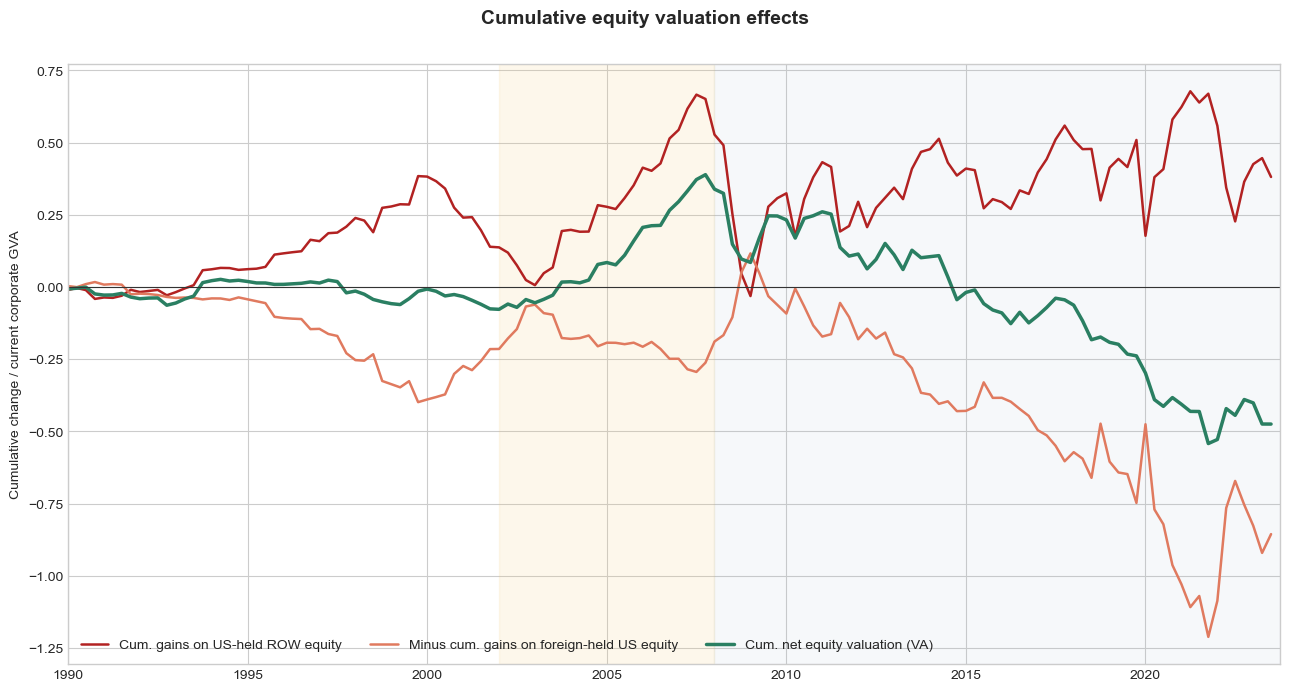

Maximum absolute cumulative VA component error: 1.110e-16


In [12]:
fig, ax = plt.subplots(figsize=(13, 6.8))
ax.plot(
    sample.index,
    sample["cum_gain_us_held_row_equity_over_gva"],
    color=COLORS["red"],
    linewidth=1.8,
    label="Cum. gains on US-held ROW equity",
)
ax.plot(
    sample.index,
    -sample["cum_gain_foreign_held_us_equity_over_gva"],
    color=COLORS["red_light"],
    linewidth=1.8,
    label="Minus cum. gains on foreign-held US equity",
)
ax.plot(
    sample.index,
    sample["cum_net_equity_valuation_over_gva"],
    color=COLORS["green"],
    linewidth=2.5,
    label="Cum. net equity valuation (VA)",
)
format_time_axis(ax)
ax.set_ylabel("Cumulative change / current corporate GVA")
ax.legend(frameon=False, ncol=3, loc="lower left")
finish_figure(
    fig,
    "07_cumulative_valuation_components_over_gva.png",
    "Cumulative equity valuation effects",
)

va_component_error = (
    sample["cum_gain_us_held_row_equity_over_gva"]
    - sample["cum_gain_foreign_held_us_equity_over_gva"]
    - sample["cum_net_equity_valuation_over_gva"]
)
print(
    "Maximum absolute cumulative VA component error:",
    f"{va_component_error.abs().max():.3e}",
)

## Figure 8: cumulative current-account components

The two signed equity-purchase terms and the change in the U.S. net bond position sum to cumulative $CA$, again divided by contemporaneous U.S. corporate GVA.

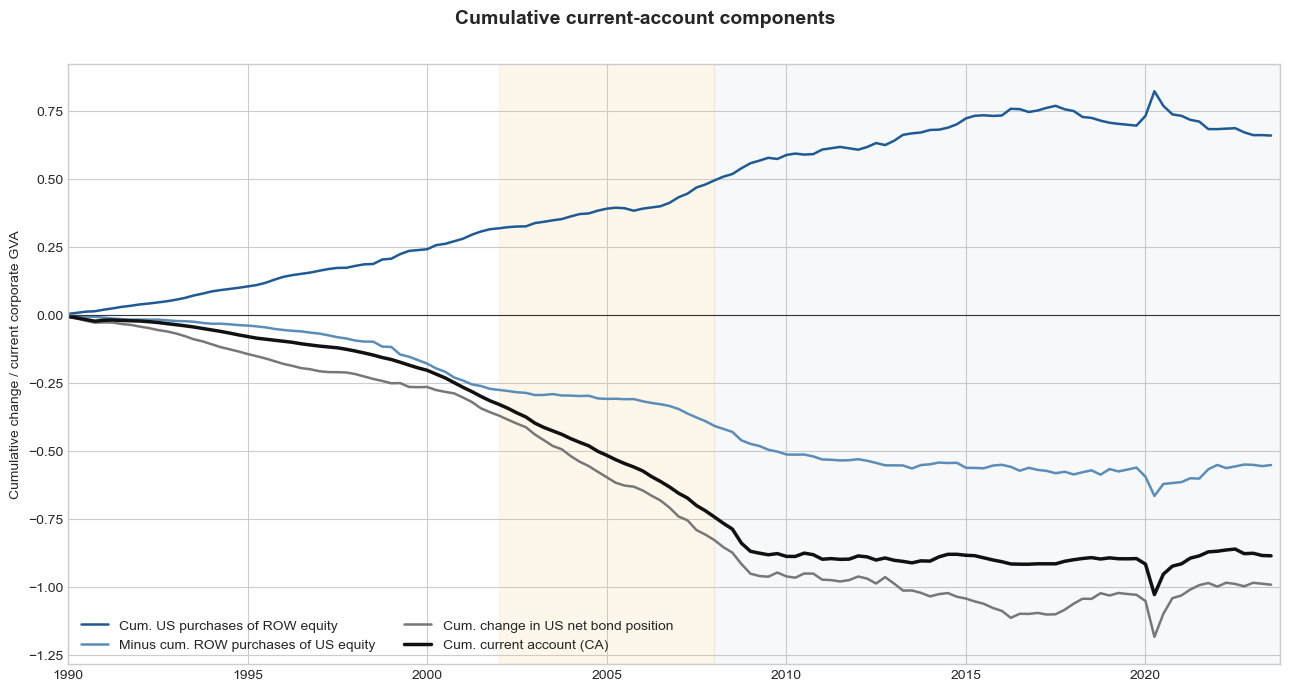

Maximum absolute cumulative CA component error: 2.220e-16


In [13]:
fig, ax = plt.subplots(figsize=(13, 6.8))
ax.plot(
    sample.index,
    sample["cum_purchase_us_of_row_equity_over_gva"],
    color=COLORS["blue"],
    linewidth=1.8,
    label="Cum. US purchases of ROW equity",
)
ax.plot(
    sample.index,
    -sample["cum_purchase_row_of_us_equity_over_gva"],
    color=COLORS["blue_light"],
    linewidth=1.8,
    label="Minus cum. ROW purchases of US equity",
)
ax.plot(
    sample.index,
    sample["cum_delta_bond_ca_closing_over_gva"],
    color=COLORS["gray"],
    linewidth=1.8,
    label="Cum. change in US net bond position",
)
ax.plot(
    sample.index,
    sample["cum_current_account_us_over_gva"],
    color=COLORS["black"],
    linewidth=2.5,
    label="Cum. current account (CA)",
)
format_time_axis(ax)
ax.set_ylabel("Cumulative change / current corporate GVA")
ax.legend(frameon=False, ncol=2, loc="lower left")
finish_figure(
    fig,
    "08_cumulative_current_account_components_over_gva.png",
    "Cumulative current-account components",
)

ca_component_error = (
    sample["cum_purchase_us_of_row_equity_over_gva"]
    - sample["cum_purchase_row_of_us_equity_over_gva"]
    + sample["cum_delta_bond_ca_closing_over_gva"]
    - sample["cum_current_account_us_over_gva"]
)
print(
    "Maximum absolute cumulative CA component error:",
    f"{ca_component_error.abs().max():.3e}",
)

## Interpretation

The plots are designed to reveal the three AHP phases:

1. **1990-2001:** NFA mostly follows cumulative current-account deficits.
2. **2002-2007:** valuation privilege - gains on US-held foreign equity exceed gains accruing to foreigners on US equity.
3. **Post-2007:** the sign reverses. Capital gains on foreign-held US equity dominate, producing a large negative net equity valuation term even though net US equity purchases are generally positive for NFA.

Because these are current-vintage FRED data, numerical paths may differ slightly from AHP's published replication vintage. Moreover, `total_valuation_us_musd` is observed total valuation; it is not a bubble-specific valuation component.